In [1]:
import datetime
import json
from os.path import join

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyliftover
import seaborn as sns
import scipy.stats as stats

from analysis_functions import classify_mutation_pair
from annotating_nmd import * 

## 1. Dataframe creation and variant filtering

Convert chromosomes files into tables and combine everything into one dataframe.

In [2]:
DATA_PATH = "processed_data"

In [3]:
chromosomes = ['chr' + str(i) for i in range(1, 23)]  # only autosomes
frames = [pd.read_table(join(DATA_PATH, f"gnomad.exomes.v4.1.sites.{chromosome}_parsed.tsv")) for chromosome in chromosomes]

/tmp/ipykernel_3137530/1365829085.py:2: DtypeWarning: Columns (24,25,26,27,28,29,30,31,43,44,50,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  frames = [pd.read_table(join(DATA_PATH, f"gnomad.exomes.v4.1.sites.{chromosome}_parsed.tsv")) for chromosome in chromosomes]
/tmp/ipykernel_3137530/1365829085.py:2: DtypeWarning: Columns (24,25,26,27,28,29,30,31,50,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  frames = [pd.read_table(join(DATA_PATH, f"gnomad.exomes.v4.1.sites.{chromosome}_parsed.tsv")) for chromosome in chromosomes]
/tmp/ipykernel_3137530/1365829085.py:2: DtypeWarning: Columns (24,25,26,27,28,29,30,31,51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  frames = [pd.read_table(join(DATA_PATH, f"gnomad.exomes.v4.1.sites.{chromosome}_parsed.tsv")) for chromosome in chromosomes]
/tmp/ipykernel_3137530/1365829085.py:2: DtypeWarning: Columns (24,26,27,28,29,30,31,51,52) have m

In [4]:
all_chrom_df = pd.concat(frames)

In [5]:
all_chrom_df.shape

(95890859, 54)

In [5]:
all_chrom_df.shape # old

(67528142, 14)

In [6]:
all_chrom_df.dtypes

CHROM                object
POS                   int64
ID                   object
REF                  object
ALT                  object
AC                    int64
AC_afr                int64
AC_amr                int64
AC_nfe                int64
AC_asj                int64
AC_sas                int64
AC_eas                int64
AC_mid                int64
AC_fin                int64
AN                    int64
AN_afr                int64
AN_amr                int64
AN_nfe                int64
AN_asj                int64
AN_sas                int64
AN_eas                int64
AN_mid                int64
AN_fin                int64
AF                  float64
AF_afr               object
AF_amr               object
AF_nfe               object
AF_asj               object
AF_sas               object
AF_eas               object
AF_mid               object
AF_fin               object
Consequence          object
IMPACT               object
SYMBOL               object
Gene                

In [9]:
all_chrom_df.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'AC', 'AC_afr', 'AC_amr', 'AC_nfe',
       'AC_asj', 'AC_sas', 'AC_eas', 'AC_mid', 'AC_fin', 'AN', 'AN_afr',
       'AN_amr', 'AN_nfe', 'AN_asj', 'AN_sas', 'AN_eas', 'AN_mid', 'AN_fin',
       'AF', 'AF_afr', 'AF_amr', 'AF_nfe', 'AF_asj', 'AF_sas', 'AF_eas',
       'AF_mid', 'AF_fin', 'Consequence', 'IMPACT', 'SYMBOL', 'Gene',
       'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'cDNA_position', 'CDS_position',
       'Protein_position', 'Amino_acids', 'Codons', 'ALLELE_NUM', 'STRAND',
       'FLAGS', 'VARIANT_CLASS', 'CANONICAL', 'LoF', 'LoF_filter', 'LoF_flags',
       'LoF_info'],
      dtype='object')

In [10]:
all_chrom_df = all_chrom_df.drop(['AC_afr', 'AC_amr', 'AC_nfe',
       'AC_asj', 'AC_sas', 'AC_eas', 'AC_mid', 'AC_fin', 'AN', 'AN_afr',
       'AN_amr', 'AN_nfe', 'AN_asj', 'AN_sas', 'AN_eas', 'AN_mid', 'AN_fin',
       'AF', 'AF_afr', 'AF_amr', 'AF_nfe', 'AF_asj', 'AF_sas', 'AF_eas',
       'AF_mid', 'AF_fin'], axis=1)

In [11]:
all_chrom_df.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'AC', 'Consequence', 'IMPACT',
       'SYMBOL', 'Gene', 'Feature', 'BIOTYPE', 'EXON', 'INTRON',
       'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids',
       'Codons', 'ALLELE_NUM', 'STRAND', 'FLAGS', 'VARIANT_CLASS', 'CANONICAL',
       'LoF', 'LoF_filter', 'LoF_flags', 'LoF_info'],
      dtype='object')

In [12]:
all_chrom_df.head()

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,Codons,ALLELE_NUM,STRAND,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info
0,chr1,12541,NaN,C,G,1,intron_variant&non_coding_transcript_variant,MODIFIER,DDX11L1,ENSG00000223972,...,NaN,1,1,NaN,SNV,YES,NaN,NaN,NaN,NaN
1,chr1,12541,NaN,C,G,1,downstream_gene_variant,MODIFIER,WASH7P,ENSG00000227232,...,NaN,1,-1,NaN,SNV,YES,NaN,NaN,NaN,NaN
2,chr1,12541,NaN,C,G,1,downstream_gene_variant,MODIFIER,MIR6859-1,ENSG00000278267,...,NaN,1,-1,NaN,SNV,YES,NaN,NaN,NaN,NaN
3,chr1,12591,rs1553119381,C,T,5,intron_variant&non_coding_transcript_variant,MODIFIER,DDX11L1,ENSG00000223972,...,NaN,1,1,NaN,SNV,YES,NaN,NaN,NaN,NaN
4,chr1,12591,rs1553119381,C,T,5,downstream_gene_variant,MODIFIER,WASH7P,ENSG00000227232,...,NaN,1,-1,NaN,SNV,YES,NaN,NaN,NaN,NaN


### Data distribution analysis

#### Representation of the loss of function (LOF) variants

In [15]:
high_counts = all_chrom_df[all_chrom_df['IMPACT'].str.contains("HIGH", na=False)].shape[0]
high_counts_clean = len(all_chrom_df[(all_chrom_df['IMPACT'].str.contains("HIGH", na=False)) & 
                                         (all_chrom_df['LoF_flags'].isnull()) &
                                         (all_chrom_df['LoF_filter'].isnull())])

print("Total number of LOF variants on automosmas:", high_counts)
print("Total number of LOF variants without flags/filters on automosmas:", high_counts_clean)


Total number of LOF variants on automosmas: 757409
Total number of LOF variants without flags/filters on automosmas: 639171


In [16]:
total_variant_count = all_chrom_df.shape[0]
per_lof = round(high_counts * 100 / total_variant_count, 2)
per_lof_clean = round(high_counts_clean * 100 / total_variant_count, 1)

print(f"Autosomes contain {per_lof}% of LoF in total, of which {per_lof_clean}% do not contain LoF flags/filters.")


Autosomes contain 0.79% of LoF in total, of which 0.7% do not contain LoF flags/filters.


#### LOF flags and filters analysis

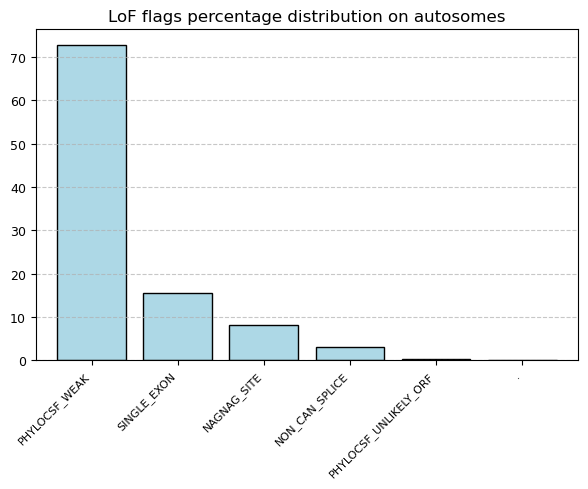

In [18]:
counts_LoF_flag = all_chrom_df['LoF_flags'].value_counts()
percentages_LoF_flag = counts_LoF_flag / counts_LoF_flag.sum() * 100

plt.figure(figsize=(6, 5))
percentages_LoF_flag.plot(kind='bar', color='lightblue', edgecolor='black', width=0.8)
plt.title('LoF flags percentage distribution on autosomes', fontsize=12)
#plt.xlabel('Flags', fontsize=12)
plt.xlabel('')
#plt.ylabel('Percentage', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('images/lof_flag_counts.png', bbox_inches='tight', dpi=300)
plt.show()

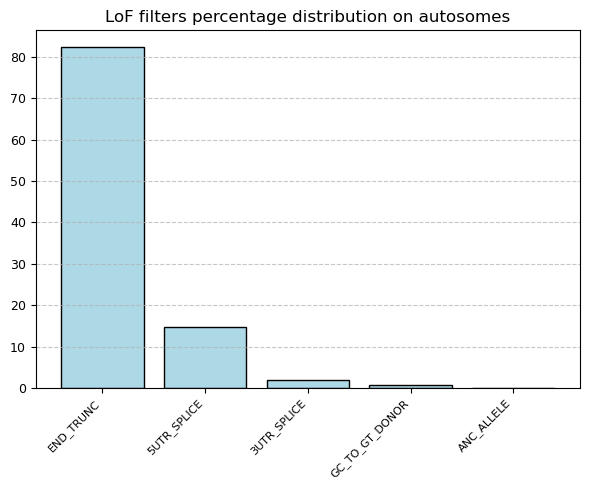

In [19]:
counts_LoF_filter = all_chrom_df['LoF_filter'].value_counts()
percentages_LoF_filter = counts_LoF_filter / counts_LoF_filter.sum() * 100

plt.figure(figsize=(6, 5))
percentages_LoF_filter.plot(kind='bar', color='lightblue', edgecolor='black', width=0.8)
plt.title('LoF filters percentage distribution on autosomes', fontsize=12)
#plt.xlabel('Filters', fontsize=12)
plt.xlabel('')
#plt.ylabel('Percentage', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('images/lof_filter_counts.png', bbox_inches='tight', dpi=300)
plt.show()

#### Variants distribution by impact

In [20]:
impact_categories = ['HIGH', 'MODERATE', 'LOW', 'MODIFIER']
impact = all_chrom_df[all_chrom_df['IMPACT'].isin(impact_categories)]

impact_counts = impact['IMPACT'].value_counts()
impact_counts

IMPACT
MODIFIER    75121451
MODERATE    12297927
LOW          7714072
HIGH          757409
Name: count, dtype: int64

In theory, the ratio of variants with `high + moderate` impact to `low` impact should be approximately 2:1, but in real populations various shifts are possible, and in this case we observe a distribution of 1,8 to 1.

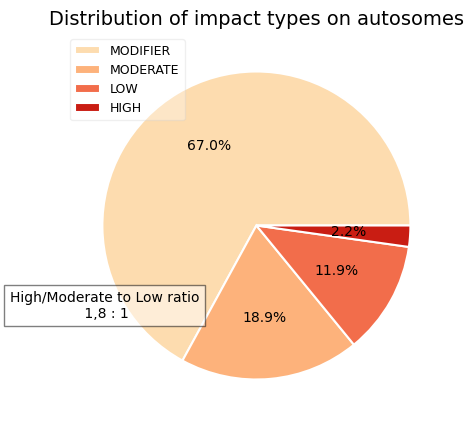

In [42]:
colors = list(sns.color_palette('OrRd', len(impact_counts)))

plt.figure(figsize=(5, 5))
labels = impact_counts.index
#explode = [0.12, 0, 0, 0]
plt.pie(impact_counts, 
                            autopct='%1.1f%%', 
                            textprops={'fontsize': 10}, 
                            #startangle=170,
                            colors=colors, 
                            wedgeprops=dict(edgecolor='white', 
                            linewidth=1.5),
                            #explode=explode
       )

plt.legend(labels, loc='upper left', fontsize=9, framealpha = 0.3)
plt.title('Distribution of impact types on autosomes', fontsize=14)
plt.text(-1.6, -0.6, 
         'High/Moderate to Low ratio\n                 1,8 : 1', 
         fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.savefig('images/impact_counts_autosomes.png', bbox_inches='tight', dpi=300)
plt.show()


## Data filtering

Leave only single-nucleotide stopgains.

In [92]:
lof_final_df = all_chrom_df[all_chrom_df['Consequence'] == 'stop_gained']

In [23]:
lof_final_df['Consequence'].value_counts()

Consequence
stop_gained    409497
Name: count, dtype: int64

In [24]:
lof_final_df['CANONICAL'].value_counts()

CANONICAL
YES    409497
Name: count, dtype: int64

Remove variants that contain LOF flags and LOF filters.

In [26]:
lof_final_df['LoF_flags'].value_counts()

LoF_flags
PHYLOCSF_WEAK            62097
SINGLE_EXON              13772
PHYLOCSF_UNLIKELY_ORF      225
.                           10
Name: count, dtype: int64

In [28]:
lof_final_df[lof_final_df['LoF_flags'] == '.']

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,Codons,ALLELE_NUM,STRAND,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info
5516451,chr1,152304887,rs762663523,C,T,20,stop_gained,HIGH,FLG,ENSG00000143631,...,tgG/tgA,1,-1,NaN,SNV,YES,LC,END_TRUNC,.,.
4259220,chr3,151881512,rs953734807,G,A,6,stop_gained,HIGH,SUCNR1,ENSG00000198829,...,tgG/tgA,1,1,NaN,SNV,YES,LC,END_TRUNC,.,.
2397137,chr5,135446760,rs12520799,T,A,704786,stop_gained,HIGH,DCANP1,ENSG00000251380,...,Aga/Tga,1,-1,NaN,SNV,YES,LC,END_TRUNC,.,.
3952810,chr7,142667240,rs1320586299,C,T,24,stop_gained,HIGH,MTRNR2L6,ENSG00000270672,...,Cga/Tga,1,1,NaN,SNV,YES,LC,END_TRUNC,.,.
5734634,chr11,124543298,rs761420752,A,C,1,stop_gained,HIGH,OR8B12,ENSG00000170953,...,taT/taG,1,-1,NaN,SNV,YES,LC,END_TRUNC,.,.
1507922,chr13,113404402,rs892418650,C,T,2,stop_gained,HIGH,ADPRHL1,ENSG00000153531,...,tGg/tAg,1,-1,NaN,SNV,YES,LC,END_TRUNC,.,.
5168699,chr16,89195062,rs749120032,C,A,1,stop_gained,HIGH,CDH15,ENSG00000129910,...,tgC/tgA,1,1,NaN,SNV,YES,LC,END_TRUNC,.,.
5168721,chr16,89195074,rs2270416,C,A,67971,stop_gained,HIGH,CDH15,ENSG00000129910,...,taC/taA,1,1,NaN,SNV,YES,LC,END_TRUNC,.,.
6842898,chr19,57131414,rs9973206,C,A,1258597,stop_gained,HIGH,USP29,ENSG00000131864,...,taC/taA,1,1,NaN,SNV,YES,LC,END_TRUNC,.,.
185872,chr20,3044792,rs1474588424,C,T,5,stop_gained,HIGH,GNRH2,ENSG00000125787,...,Cag/Tag,1,1,NaN,SNV,YES,LC,END_TRUNC,.,.


In [27]:
lof_final_df['LoF_filter'].value_counts()

LoF_filter
END_TRUNC     44922
ANC_ALLELE       12
Name: count, dtype: int64

In [93]:
lof_final_df = lof_final_df[lof_final_df['LoF_filter'].isnull()]
lof_final_df = lof_final_df[lof_final_df['LoF_flags'].isnull()]

In [94]:
lof_final_df.shape

(312205, 28)

In [95]:
lof_final_df['LoF'].value_counts()

LoF
HC    309290
Name: count, dtype: int64

In [96]:
lof_final_df['REF'].unique()

array(['T', 'C', 'A', 'G'], dtype=object)

In [97]:
lof_final_df['ALT'].unique()

array(['A', 'T', 'G', 'C'], dtype=object)

In [98]:
lof_final_df

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,Codons,ALLELE_NUM,STRAND,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info
411,chr1,69548,rs1211934440,T,A,1,stop_gained,HIGH,OR4F5,ENSG00000186092,...,tTg/tAg,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.531090723751274
17490,chr1,924595,NaN,C,A,1,stop_gained,HIGH,SAMD11,ENSG00000187634,...,tCg/tAg,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0646942800788955
17769,chr1,925933,rs1409697303,A,T,1,stop_gained,HIGH,SAMD11,ENSG00000187634,...,Aag/Tag,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.208678500986193
17794,chr1,925960,NaN,C,T,1,stop_gained,HIGH,SAMD11,ENSG00000187634,...,Cag/Tag,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.219329388560158
17830,chr1,925996,NaN,C,T,2,stop_gained,HIGH,SAMD11,ENSG00000187634,...,Cga/Tga,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.23353057199211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2488635,chr22,50769106,rs559977293,G,A,173,stop_gained,HIGH,RABL2B,ENSG00000079974,...,Cga/Tga,1,-1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.76231884057971
2488950,chr22,50769969,NaN,C,T,1,stop_gained,HIGH,RABL2B,ENSG00000079974,...,tgG/tgA,1,-1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.5
2489459,chr22,50775796,rs1555923164,G,T,1,stop_gained,HIGH,RABL2B,ENSG00000079974,...,taC/taA,1,-1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.395652173913043
2489499,chr22,50775845,NaN,C,T,2,stop_gained,HIGH,RABL2B,ENSG00000079974,...,tGg/tAg,1,-1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.32463768115942


In [39]:
lof_final_df['Feature'].value_counts()

Feature
ENST00000589042    897
ENST00000680850    486
ENST00000367255    393
ENST00000454784    365
ENST00000682510    296
                  ... 
ENST00000401088      1
ENST00000292807      1
ENST00000541810      1
ENST00000616316      1
ENST00000408968      1
Name: count, Length: 16719, dtype: int64

In [99]:
has_na = lof_final_df['Feature'].isna().any()
print(has_na)

False


In [100]:
unique_count = lof_final_df['POS'].nunique()
print(unique_count)

304631


In [101]:
lof_final_df.to_csv('data/lof_final_wo_loeuf_and_pext.csv', index=False)

### Add LOEUF score

The loss-of-function observed over expected upper bound fraction, or [LOEUF score](https://doi.org/10.1007/s00439-022-02509-x), is a metric that places each gene on a continuous scale of loss-of-function constraint. Low scores are highly correlated with disease genes and gene essentiality. 
  
Due to expected shifts in the LOEUF distribution between gnomAD v2.1.1 and v4.0, it recommemded to use a threshold of LOEUF < 0.6 for v4.0 and [LOEUF < 0.35 for v2](https://gnomad.broadinstitute.org/news/2024-03-gnomad-v4-0-gene-constraint/#loeuf-guidance). We use the threshold for gnomAD v.2 because data on LOEUF were taken specifically for this dataset.

Convert a file with metrics into a dataframe.

In [2]:
lof_final_df = pd.read_csv('data/lof_final_wo_loeuf_and_pext.csv')

In [3]:
lof_metrics_by_gene = pd.read_table('/home/bar-1/gnomad_v2_metrics/gnomad.v2.1.1.lof_metrics.by_transcript.txt')
lof_metrics_by_gene

,gene,transcript,canonical,obs_mis,exp_mis,oe_mis,mu_mis,possible_mis,obs_mis_pphen,exp_mis_pphen,...,gene_type,gene_length,exac_pLI,exac_obs_lof,exac_exp_lof,exac_oe_lof,brain_expression,chromosome,start_position,end_position
0,A1BG,ENST00000263100,True,298.0,293.850,1.01410,0.000019,3115.0,104.0,101.3900,...,protein_coding,8322,0.000091,8.0,12.301,0.65033,NaN,19,58856544,58864865
1,A1BG,ENST00000600966,False,180.0,176.690,1.01870,0.000012,1941.0,66.0,57.9780,...,protein_coding,8322,NaN,NaN,NaN,NaN,NaN,19,58856544,58864865
2,A1CF,ENST00000282641,False,282.0,329.520,0.85578,0.000017,3828.0,85.0,114.1900,...,protein_coding,86267,NaN,NaN,NaN,NaN,NaN,10,52559169,52645435
3,A1CF,ENST00000373993,False,282.0,329.520,0.85578,0.000017,3828.0,85.0,114.1900,...,protein_coding,86267,NaN,NaN,NaN,NaN,NaN,10,52559169,52645435
4,A1CF,ENST00000373995,True,274.0,324.180,0.84521,0.000016,3829.0,100.0,138.3900,...,protein_coding,86267,0.003620,9.0,25.937,0.34700,NaN,10,52559169,52645435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80945,ZZZ3,ENST00000433749,False,22.0,34.236,0.64259,0.000002,347.0,14.0,26.3000,...,protein_coding,121004,NaN,NaN,NaN,NaN,NaN,1,78028101,78149104
80946,hsa-mir-1199,ENST00000269720,True,102.0,153.190,0.66582,0.000007,2234.0,31.0,45.8790,...,protein_coding,2527,NaN,NaN,NaN,NaN,NaN,19,14183348,14185874
80947,hsa-mir-1199,ENST00000587086,False,59.0,74.035,0.79692,0.000004,1339.0,26.0,38.4770,...,protein_coding,2527,NaN,NaN,NaN,NaN,NaN,19,14183348,14185874
80948,hsa-mir-1199,ENST00000590772,False,40.0,58.472,0.68408,0.000003,889.0,NaN,NaN,...,protein_coding,2527,NaN,NaN,NaN,NaN,NaN,19,14183348,14185874


Create a dictionary "transcript": "LOEUF value".

In [4]:
loeuf_by_transcript_dict = dict(zip(lof_metrics_by_gene['transcript'], lof_metrics_by_gene['oe_lof_upper']))

In [5]:
len(loeuf_by_transcript_dict)

80950

Write all matches to transcript keys in the LOEUF column.

In [6]:
lof_final_df.loc[:, 'LOEUF'] = lof_final_df['Feature'].map(loeuf_by_transcript_dict)

In [7]:
lof_final_df

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,ALLELE_NUM,STRAND,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF
0,chr1,69548,rs1211934440,T,A,1,stop_gained,HIGH,OR4F5,ENSG00000186092,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.531090723751274,NaN
1,chr1,924595,NaN,C,A,1,stop_gained,HIGH,SAMD11,ENSG00000187634,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0646942800788955,NaN
2,chr1,925933,rs1409697303,A,T,1,stop_gained,HIGH,SAMD11,ENSG00000187634,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.208678500986193,NaN
3,chr1,925960,NaN,C,T,1,stop_gained,HIGH,SAMD11,ENSG00000187634,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.219329388560158,NaN
4,chr1,925996,NaN,C,T,2,stop_gained,HIGH,SAMD11,ENSG00000187634,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.23353057199211,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312200,chr22,50769106,rs559977293,G,A,173,stop_gained,HIGH,RABL2B,ENSG00000079974,...,1,-1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.76231884057971,NaN
312201,chr22,50769969,NaN,C,T,1,stop_gained,HIGH,RABL2B,ENSG00000079974,...,1,-1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.5,NaN
312202,chr22,50775796,rs1555923164,G,T,1,stop_gained,HIGH,RABL2B,ENSG00000079974,...,1,-1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.395652173913043,NaN
312203,chr22,50775845,NaN,C,T,2,stop_gained,HIGH,RABL2B,ENSG00000079974,...,1,-1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.32463768115942,NaN


In [8]:
lof_final_df['LOEUF'].value_counts()

LOEUF
0.354    1141
0.640     815
0.857     731
0.837     689
0.456     597
         ... 
0.056       1
1.440       1
1.960       1
1.886       1
1.962       1
Name: count, Length: 1922, dtype: int64

In [9]:
filtered_lof = lof_final_df[lof_final_df['LOEUF'].isna()]
without_loeuf = filtered_lof['Feature'].unique()
print(without_loeuf)

found_pairs = []

for feature in without_loeuf:
    if feature in loeuf_by_transcript_dict:
        found_pairs.append((feature, loeuf_by_transcript_dict[feature]))

found_pairs

['ENST00000641515' 'ENST00000616016' 'ENST00000673477' ...
 'ENST00000674500' 'ENST00000612753' 'ENST00000691320']


[('ENST00000392653', nan),
 ('ENST00000368755', nan),
 ('ENST00000355281', nan),
 ('ENST00000505059', nan),
 ('ENST00000394323', nan),
 ('ENST00000603053', nan),
 ('ENST00000356818', nan),
 ('ENST00000422359', nan),
 ('ENST00000488181', nan),
 ('ENST00000556887', nan),
 ('ENST00000555004', nan),
 ('ENST00000311755', nan),
 ('ENST00000322301', nan),
 ('ENST00000594383', nan),
 ('ENST00000304748', nan),
 ('ENST00000339223', nan),
 ('ENST00000599599', nan),
 ('ENST00000360816', nan)]

Leave only highly conservative options (LOEUF < 0.35):

In [10]:
lof_final_df = lof_final_df[lof_final_df['LOEUF'] < 0.35]

In [11]:
lof_final_df.shape

(36729, 29)

In [12]:
lof_final_df

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,ALLELE_NUM,STRAND,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF
744,chr1,1825438,rs867938404,G,A,1,stop_gained,HIGH,GNB1,ENSG00000078369,...,1,-1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0156402737047898,0.145
822,chr1,2024966,NaN,C,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0684326710816777,0.245
823,chr1,2024966,NaN,C,G,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0684326710816777,0.245
824,chr1,2024993,NaN,G,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0883002207505519,0.245
825,chr1,2025553,NaN,G,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.209713024282561,0.245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312185,chr22,50721176,NaN,C,T,1,stop_gained,HIGH,SHANK3,ENSG00000251322,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.61028192371476,0.123
312186,chr22,50721521,NaN,G,T,5,stop_gained,HIGH,SHANK3,ENSG00000251322,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.681799336650083,0.123
312187,chr22,50721995,NaN,G,T,2,stop_gained,HIGH,SHANK3,ENSG00000251322,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.780058043117745,0.123
312188,chr22,50722415,NaN,A,T,1,stop_gained,HIGH,SHANK3,ENSG00000251322,...,1,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.86712271973466,0.123


In [13]:
lof_final_df.to_csv('data/lof_final_with_loeuf_and_wo_pext.csv', index=False)

### Add pext score

Information about pext boundaries is taken from [Singer-Berk M et al, 2023](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10029069/).

In [14]:
lof_final_df = pd.read_csv('data/lof_final_with_loeuf_and_wo_pext.csv')

In [15]:
header_pext = ['chrom', 'pos', 'ref', 'alt', 'tx_annotation']

Convert a file containing the pext score values (only for stopgains) into a dataframe.

In [16]:
pext_raw_df = pd.read_table("/home/bar-1/gnomad_v2_metrics/all.stopgains.tx_annotated.GTEx.v7.021520.tsv", names=header_pext)

/tmp/ipykernel_3181657/2080261526.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  pext_raw_df = pd.read_table("/home/bar-1/gnomad_v2_metrics/all.stopgains.tx_annotated.GTEx.v7.021520.tsv", names=header_pext)


In [17]:
pext_raw_df

,chrom,pos,ref,alt,tx_annotation
0,1,69100,G,T,"[{""ensg"":""ENSG00000186092"",""csq"":""stop_gained""..."
1,1,69130,C,T,"[{""ensg"":""ENSG00000186092"",""csq"":""stop_gained""..."
2,1,69133,G,T,"[{""ensg"":""ENSG00000186092"",""csq"":""stop_gained""..."
3,1,69139,C,T,"[{""ensg"":""ENSG00000186092"",""csq"":""stop_gained""..."
4,1,69158,T,A,"[{""ensg"":""ENSG00000186092"",""csq"":""stop_gained""..."
...,...,...,...,...,...
4365545,Y,28111983,C,A,"[{""ensg"":""ENSG00000269393"",""csq"":""stop_gained""..."
4365546,Y,28114877,T,A,"[{""ensg"":""ENSG00000269393"",""csq"":""stop_gained""..."
4365547,Y,28114879,A,C,"[{""ensg"":""ENSG00000269393"",""csq"":""stop_gained""..."
4365548,Y,28114879,A,T,"[{""ensg"":""ENSG00000269393"",""csq"":""stop_gained""..."


In [18]:
tx_annotation_data = pext_raw_df['tx_annotation'].apply(lambda x: json.loads(x.replace("'", "\""))[0])
pext_tx_annotation = pd.DataFrame(tx_annotation_data.tolist())
pext_hg19_df = pd.concat([pext_raw_df.drop(columns=['tx_annotation']), pext_tx_annotation], axis=1)

In [19]:
pext_hg19_df = pext_hg19_df[(pext_hg19_df['chrom'] != 'X') & (pext_hg19_df['chrom'] != 'Y')]

Convert position values from hg19 to hg38.

In [20]:
pext_hg38_df = pext_hg19_df.copy()
pext_hg38_df['chrom'] = pext_hg38_df['chrom'].apply(lambda x: 'chr' + str(x))

In [21]:
lo = pyliftover.LiftOver('hg19', 'hg38')

for index, row in pext_hg38_df.iterrows():
    try:
        converted = lo.convert_coordinate(row['chrom'], row['pos'])
        if converted:
            pext_hg38_df.loc[index, 'chrom'] = converted[0][0]
            pext_hg38_df.loc[index, 'pos'] = converted[0][1]
    except Exception as e:
        print(f"Error converting coordinates for index {index}: {e}")

IOStream.flush timed out


In [22]:
pext_dict = {(row['chrom'], row['pos'], row['ref'], row['alt']): row['mean_proportion'] for _, row in pext_hg38_df.iterrows()}

In [23]:
for index, row in lof_final_df.iterrows():
    key = (row['CHROM'], row['POS'], row['REF'], row['ALT'])
    
    if key in pext_dict:
        lof_final_df.loc[index, 'pext'] = pext_dict[key]
    else:
        lof_final_df.loc[index, 'pext'] = None

/tmp/ipykernel_3181657/201323663.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NaN' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  lof_final_df.loc[index, 'pext'] = pext_dict[key]


In [24]:
lof_final_df

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,STRAND,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF,pext
0,chr1,1825438,rs867938404,G,A,1,stop_gained,HIGH,GNB1,ENSG00000078369,...,-1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0156402737047898,0.145,0.966547
1,chr1,2024966,NaN,C,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0684326710816777,0.245,1.0
2,chr1,2024966,NaN,C,G,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0684326710816777,0.245,1.0
3,chr1,2024993,NaN,G,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0883002207505519,0.245,1.0
4,chr1,2025553,NaN,G,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.209713024282561,0.245,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36724,chr22,50721176,NaN,C,T,1,stop_gained,HIGH,SHANK3,ENSG00000251322,...,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.61028192371476,0.123,1.0
36725,chr22,50721521,NaN,G,T,5,stop_gained,HIGH,SHANK3,ENSG00000251322,...,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.681799336650083,0.123,1.0
36726,chr22,50721995,NaN,G,T,2,stop_gained,HIGH,SHANK3,ENSG00000251322,...,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.780058043117745,0.123,1.0
36727,chr22,50722415,NaN,A,T,1,stop_gained,HIGH,SHANK3,ENSG00000251322,...,1,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.86712271973466,0.123,1.0


In [25]:
lof_final_df['pext'].value_counts()

pext
1.000000    2720
0.217287     163
0.243524     136
0.363592     128
0.156110     118
            ... 
0.774540       1
0.165323       1
0.960645       1
0.703718       1
0.604463       1
Name: count, Length: 6475, dtype: int64

Keep only higher expressing variants (pext > 0.5):

In [26]:
lof_final_df['pext'] = lof_final_df['pext'].astype(float)
lof_final_df = lof_final_df[lof_final_df['pext'] > 0.5]

In [27]:
lof_final_df['pext'].value_counts()

pext
1.000000    2720
0.621111      71
0.999846      70
0.999478      70
0.859845      63
            ... 
0.780455       1
0.501519       1
0.999130       1
0.727257       1
0.737987       1
Name: count, Length: 4519, dtype: int64

In [28]:
lof_final_df.shape

(25583, 30)

In [29]:
lof_final_df.to_csv('data/lof_final_with_loeuf_and_pext.csv', index=False)

### Get NMD-escaping regions info

We use the code from [Torene et al., 2024](https://doi.org/10.1016/j.ajhg.2023.11.007). Full code is available [here](https://github.com/rebeccaito/nmd-escape/tree/main).

First obtain the required bed file for our data.

In [30]:
cds_bed_df = pd.read_table('/home/bar-1/gencode_data/gencode.v47.annotation.bed', names=['chrom', 'start', 'end', 'cds_id', 'score', 'strand'])

cds_bed_df['cds_id'] = (cds_bed_df['cds_id'] + '_cds_0_0_' +
                              cds_bed_df['chrom'] + '_' +
                              (cds_bed_df['start'] + 1).astype(str) + '_' +
                              cds_bed_df['strand'].map({'+': 'f', '-': 'r'}))

In [31]:
cds_bed_df

,chrom,start,end,cds_id,score,strand
0,chr1,65564,65573,ENST00000641515.2_cds_0_0_chr1_65565_f,.,+
1,chr1,69036,70005,ENST00000641515.2_cds_0_0_chr1_69037_f,.,+
2,chr1,450742,451678,ENST00000426406.4_cds_0_0_chr1_450743_r,.,-
3,chr1,685718,686654,ENST00000332831.5_cds_0_0_chr1_685719_r,.,-
4,chr1,924431,924948,ENST00000616016.5_cds_0_0_chr1_924432_f,.,+
...,...,...,...,...,...,...
901763,chrM,10469,10763,ENST00000361335.1_cds_0_0_chrM_10470_f,.,+
901764,chrM,10759,12137,ENST00000361381.2_cds_0_0_chrM_10760_f,.,+
901765,chrM,12336,14145,ENST00000361567.2_cds_0_0_chrM_12337_f,.,+
901766,chrM,14148,14673,ENST00000361681.2_cds_0_0_chrM_14149_r,.,-


Determine NMD regions from a 6-column bed file of coding sequence regions.

In [32]:
nmd_bed_df = make_boundaries_df(cds_bed_df)

In [33]:
nmd_bed_df

index  chrom      start        end  \
transcript_name                                             
ENST00000000233.10 0  365990   chr7  127591212  127591296   
                   1  365989   chr7  127591033  127591088   
ENST00000000412.8  0  538779  chr12    8941820    8941940   
                   1  538778  chr12    8942415    8942470   
ENST00000000442.11 0  503425  chr11   64315706   64315963   
...                      ...    ...        ...        ...   
ENST00000850691.1  1  899953   chrY    1305472    1305527   
ENST00000850822.1  0  899777   chrY     305076     305197   
                   1  899776   chrY     307359     307414   
ENST00000850823.1  0  901744   chrY   57196335   57196369   
                   1  901743   chrY   57192653   57192708   

                                                           cds_id score  \
transcript_name                                                           
ENST00000000233.10 0  ENST00000000233.10_cds_0_0_chr7_127591213_f     .   
                   1  ENST00000000233.10_cds_0_0_chr7_127590963_f     .   
ENST00000000412.8  0    ENST00000000412.8_cds_0_0_chr12_8941821_r     .   
                   1    ENST00000000412.8_cds_0_0_chr12_8942416_r     .   
ENST00000000442.11 0  ENST00000000442.11_cds_0_0_chr11_64315707_f     .   
...                                                           ...   ...   
ENST00000850691.1  1     ENST00000850691.1_cds_0_0_chrY_1305446_f     .   
ENST00000850822.1  0      ENST00000850822.1_cds_0_0_chrY_305077_r     .   
                   1      ENST00000850822.1_cds_0_0_chrY_307360_r     .   
ENST00000850823.1  0    ENST00000850823.1_cds_0_0_chrY_57196336_f     .   
                   1    ENST00000850823.1_cds_0_0_chrY_57192603_f     .   

                     strand cds_size  
transcript_name                       
ENST00000000233.10 0      +       84  
                   1      +       55  
ENST00000000412.8  0      -      120  
                   1      -       55  
ENST00000000442.11 0      +      257  
...                     ...      ...  
ENST00000850691.1  1      +       55  
ENST00000850822.1  0      -      121  
                   1      -       55  
ENST00000850823.1  0      +       34  
                   1      +       55  

[216255 rows x 8 columns]

### Add NMD info to dataframe

In [34]:
nmd_bed_df = nmd_bed_df.reset_index()
# nmd_bed_df = nmd_bed_df.drop('transcript_name', axis=1)
nmd_bed_df = nmd_bed_df.drop('level_1', axis=1)
nmd_bed_df = nmd_bed_df.drop('index', axis=1)

In [35]:
nmd_bed_df = nmd_bed_df.rename(columns={'transcript_name': 'transcript'})

In [36]:
nmd_bed_df

,transcript,chrom,start,end,cds_id,score,strand,cds_size
0,ENST00000000233.10,chr7,127591212,127591296,ENST00000000233.10_cds_0_0_chr7_127591213_f,.,+,84
1,ENST00000000233.10,chr7,127591033,127591088,ENST00000000233.10_cds_0_0_chr7_127590963_f,.,+,55
2,ENST00000000412.8,chr12,8941820,8941940,ENST00000000412.8_cds_0_0_chr12_8941821_r,.,-,120
3,ENST00000000412.8,chr12,8942415,8942470,ENST00000000412.8_cds_0_0_chr12_8942416_r,.,-,55
4,ENST00000000442.11,chr11,64315706,64315963,ENST00000000442.11_cds_0_0_chr11_64315707_f,.,+,257
...,...,...,...,...,...,...,...,...
216250,ENST00000850691.1,chrY,1305472,1305527,ENST00000850691.1_cds_0_0_chrY_1305446_f,.,+,55
216251,ENST00000850822.1,chrY,305076,305197,ENST00000850822.1_cds_0_0_chrY_305077_r,.,-,121
216252,ENST00000850822.1,chrY,307359,307414,ENST00000850822.1_cds_0_0_chrY_307360_r,.,-,55
216253,ENST00000850823.1,chrY,57196335,57196369,ENST00000850823.1_cds_0_0_chrY_57196336_f,.,+,34


Search for a match by transcript. When found, check if the position falls within the boundaries.

In [37]:
%%time

mask_transcript = lof_final_df['Feature'].isin(nmd_bed_df['transcript'].str.split('.').str[0])
lof_final_df.loc[~mask_transcript, 'NMD_escape'] = 'NO_TRANSCRIPT'

for index, row in nmd_bed_df.iterrows():
    transcript_split = row['transcript'].split('.')[0]
    
    mask_all = (lof_final_df['Feature'] == transcript_split) & \
             (lof_final_df['POS'] >= row['start']) & \
             (lof_final_df['POS'] <= row['end'])
    
    lof_final_df.loc[mask_all, 'NMD_escape'] = 'YES'


lof_final_df.loc[(lof_final_df['NMD_escape'] != 'YES') & (lof_final_df['NMD_escape'] != 'NO_TRANSCRIPT'), 'NMD_escape'] = 'NO'

<timed exec>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


CPU times: user 9min 13s, sys: 625 ms, total: 9min 13s
Wall time: 9min 16s


In [38]:
lof_final_df['NMD_escape'].value_counts()

NMD_escape
NO               21116
YES               4426
NO_TRANSCRIPT       41
Name: count, dtype: int64

In [39]:
lof_final_df['NMD_escape'].value_counts() # old

NMD_escape
NO               21116
YES               4426
NO_TRANSCRIPT       41
Name: count, dtype: int64

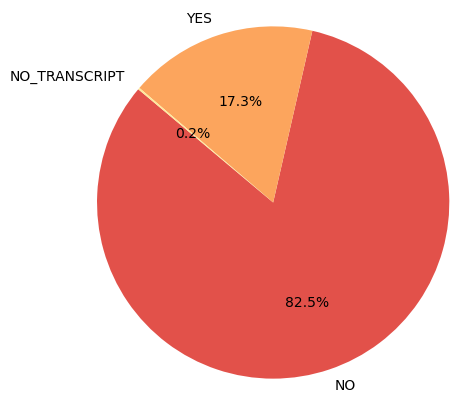

In [40]:
nmd_counts = lof_final_df['NMD_escape'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(nmd_counts, 
        labels=nmd_counts.index, 
        autopct='%1.1f%%', 
        startangle=140,
        colors=sns.color_palette("Spectral")) 
plt.axis('equal')
plt.savefig('images/nmd_counts_autosomes.png', bbox_inches='tight', dpi=300)
plt.show()


In [41]:
lof_final_df

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,FLAGS,VARIANT_CLASS,CANONICAL,LoF,LoF_filter,LoF_flags,LoF_info,LOEUF,pext,NMD_escape
0,chr1,1825438,rs867938404,G,A,1,stop_gained,HIGH,GNB1,ENSG00000078369,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0156402737047898,0.145,0.966547,NO
1,chr1,2024966,NaN,C,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0684326710816777,0.245,1.000000,NO
2,chr1,2024966,NaN,C,G,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0684326710816777,0.245,1.000000,NO
3,chr1,2024993,NaN,G,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.0883002207505519,0.245,1.000000,NO
4,chr1,2025553,NaN,G,A,1,stop_gained,HIGH,GABRD,ENSG00000187730,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.209713024282561,0.245,1.000000,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36724,chr22,50721176,NaN,C,T,1,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.61028192371476,0.123,1.000000,NO
36725,chr22,50721521,NaN,G,T,5,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.681799336650083,0.123,1.000000,NO
36726,chr22,50721995,NaN,G,T,2,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.780058043117745,0.123,1.000000,NO
36727,chr22,50722415,NaN,A,T,1,stop_gained,HIGH,SHANK3,ENSG00000251322,...,NaN,SNV,YES,HC,NaN,NaN,PERCENTILE:0.86712271973466,0.123,1.000000,YES


In [42]:
lof_final_df['LOEUF'].describe()

count    25583.000000
mean         0.237494
std          0.073897
min          0.030000
25%          0.183000
50%          0.248000
75%          0.301000
max          0.349000
Name: LOEUF, dtype: float64

In [43]:
lof_final_df['pext'].describe()

count    25583.000000
mean         0.843868
std          0.147476
min          0.500135
25%          0.733811
50%          0.890842
75%          0.975918
max          1.000000
Name: pext, dtype: float64

In [44]:
lof_final_df.to_csv('data/lof_final_with_loeuf_pext_nmdstatus.csv', index=False)

### Divide into NMD(+) and NMD(-) dataframes

In [45]:
nmd_escape_df = lof_final_df[lof_final_df['NMD_escape'] == 'YES']
nmd_undergo_df = lof_final_df[lof_final_df['NMD_escape'] == 'NO']

In [46]:
nmd_escape_df.shape  # NMD(-)

(4426, 31)

In [47]:
nmd_undergo_df.shape  # NMD(+)

(21116, 31)

In [48]:
nmd_escape_df.to_csv('data/lof_final_with_loeuf_pext_nmd_escape.csv', index=False)
nmd_undergo_df.to_csv('data/lof_final_with_loeuf_pext_nmd_undergo.csv', index=False)

## 2. Clinvar data processing

ClinVar does not contain transcripts for the variants, so first we annotate the downloaded Clinvar file (GRCh38, version 20240331) using VEP 113.

In [53]:
clinvar_df = pd.read_table('data/snp_pat_lpat_clinvar_20250421_anno.vcf.tsv')

/tmp/ipykernel_3181657/1987258720.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  clinvar_df = pd.read_table('data/snp_pat_lpat_clinvar_20250421_anno.vcf.tsv')


In [54]:
clinvar_df

,CHROM,POS,ID,REF,ALT,CLNREVSTAT,CLNSIG,CLNVC,GENEINFO,MC,...,Feature,BIOTYPE,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,STRAND,FLAGS,CANONICAL
0,chr1,943995,950448,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SAMD11:148398,SO:0001587|nonsense,...,ENST00000327044,protein_coding,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,YES
1,chr1,943995,950448,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SAMD11:148398,SO:0001587|nonsense,...,ENST00000341065,protein_coding,1611.0,1612.0,538.0,R/*,Cga/Tga,1.0,cds_start_NF,NaN
2,chr1,943995,950448,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SAMD11:148398,SO:0001587|nonsense,...,ENST00000342066,protein_coding,1978.0,1888.0,630.0,R/*,Cga/Tga,1.0,NaN,NaN
3,chr1,943995,950448,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SAMD11:148398,SO:0001587|nonsense,...,ENST00000455979,protein_coding,1467.0,1468.0,490.0,R/*,Cga/Tga,1.0,cds_start_NF,NaN
4,chr1,943995,950448,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SAMD11:148398,SO:0001587|nonsense,...,ENST00000464948,retained_intron,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2325098,chrMT,16002,690271,T,C,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,single_nucleotide_variant,MT-TP:4571,SO:0001583|missense_variant,...,ENST00000387449,Mt_tRNA,NaN,NaN,NaN,NaN,NaN,1.0,NaN,YES
2325099,chrMT,16002,690271,T,C,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,single_nucleotide_variant,MT-TP:4571,SO:0001583|missense_variant,...,ENST00000387456,Mt_tRNA,NaN,NaN,NaN,NaN,NaN,1.0,NaN,YES
2325100,chrMT,16002,690271,T,C,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,single_nucleotide_variant,MT-TP:4571,SO:0001583|missense_variant,...,ENST00000387459,Mt_tRNA,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,YES
2325101,chrMT,16002,690271,T,C,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,single_nucleotide_variant,MT-TP:4571,SO:0001583|missense_variant,...,ENST00000387460,Mt_tRNA,NaN,NaN,NaN,NaN,NaN,1.0,NaN,YES


In [55]:
clinvar_df.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'CLNREVSTAT', 'CLNSIG', 'CLNVC',
       'GENEINFO', 'MC', 'Consequence', 'SYMBOL', 'Gene', 'Feature_type',
       'Feature', 'BIOTYPE', 'cDNA_position', 'CDS_position',
       'Protein_position', 'Amino_acids', 'Codons', 'STRAND', 'FLAGS',
       'CANONICAL'],
      dtype='object')

In [56]:
clinvar_df['CLNSIG'].unique()

array(['Pathogenic', 'Pathogenic/Likely_pathogenic', 'Likely_pathogenic',
       'Pathogenic|risk_factor',
       'Pathogenic/Likely_pathogenic/Pathogenic,_low_penetrance',
       'Pathogenic/Likely_pathogenic|other',
       'Pathogenic/Likely_pathogenic|risk_factor',
       'Likely_pathogenic,_low_penetrance', 'Likely_pathogenic|other',
       'Likely_pathogenic/Likely_risk_allele', 'Pathogenic|other',
       'Pathogenic/Pathogenic,_low_penetrance|other|risk_factor',
       'Pathogenic/Likely_pathogenic/Likely_risk_allele',
       'Likely_pathogenic|Affects', 'Pathogenic|drug_response',
       'Likely_pathogenic|association', 'Pathogenic/Likely_risk_allele',
       'Pathogenic/Likely_pathogenic/Pathogenic,_low_penetrance|risk_factor',
       'Pathogenic/Pathogenic,_low_penetrance|other',
       'Pathogenic/Likely_pathogenic|association',
       'Likely_pathogenic|risk_factor', 'Likely_pathogenic|drug_response'],
      dtype=object)

In [57]:
sign_values = ['criteria_provided,_multiple_submitters,_no_conflicts', 'criteria_provided,_single_submitter',
                  'criteria_provided,_conflicting_classifications', 'reviewed_by_expert_panel', 
                  'practice_guideline']

clinvar_df = clinvar_df[clinvar_df['CLNREVSTAT'].isin(sign_values)]

In [58]:
clinvar_df

,CHROM,POS,ID,REF,ALT,CLNREVSTAT,CLNSIG,CLNVC,GENEINFO,MC,...,Feature,BIOTYPE,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,STRAND,FLAGS,CANONICAL
0,chr1,943995,950448,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SAMD11:148398,SO:0001587|nonsense,...,ENST00000327044,protein_coding,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,YES
1,chr1,943995,950448,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SAMD11:148398,SO:0001587|nonsense,...,ENST00000341065,protein_coding,1611.0,1612.0,538.0,R/*,Cga/Tga,1.0,cds_start_NF,NaN
2,chr1,943995,950448,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SAMD11:148398,SO:0001587|nonsense,...,ENST00000342066,protein_coding,1978.0,1888.0,630.0,R/*,Cga/Tga,1.0,NaN,NaN
3,chr1,943995,950448,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SAMD11:148398,SO:0001587|nonsense,...,ENST00000455979,protein_coding,1467.0,1468.0,490.0,R/*,Cga/Tga,1.0,cds_start_NF,NaN
4,chr1,943995,950448,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SAMD11:148398,SO:0001587|nonsense,...,ENST00000464948,retained_intron,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2325098,chrMT,16002,690271,T,C,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,single_nucleotide_variant,MT-TP:4571,SO:0001583|missense_variant,...,ENST00000387449,Mt_tRNA,NaN,NaN,NaN,NaN,NaN,1.0,NaN,YES
2325099,chrMT,16002,690271,T,C,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,single_nucleotide_variant,MT-TP:4571,SO:0001583|missense_variant,...,ENST00000387456,Mt_tRNA,NaN,NaN,NaN,NaN,NaN,1.0,NaN,YES
2325100,chrMT,16002,690271,T,C,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,single_nucleotide_variant,MT-TP:4571,SO:0001583|missense_variant,...,ENST00000387459,Mt_tRNA,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,YES
2325101,chrMT,16002,690271,T,C,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,single_nucleotide_variant,MT-TP:4571,SO:0001583|missense_variant,...,ENST00000387460,Mt_tRNA,NaN,NaN,NaN,NaN,NaN,1.0,NaN,YES


Add the LOEUF score info and select only conditionally highly conservative options.

In [59]:
clinvar_df.loc[:, 'LOEUF'] = clinvar_df['Feature'].map(loeuf_by_transcript_dict)

In [60]:
clinvar_df['LOEUF'].value_counts()

LOEUF
0.290    3854
0.297    3085
0.071    2914
0.710    2801
0.173    2444
         ... 
0.050       2
1.670       2
1.809       1
1.965       1
1.976       1
Name: count, Length: 1945, dtype: int64

In [61]:
clinvar_df = clinvar_df.query('LOEUF < 0.35')

Add the pext score info and select only conditionally highly conservative options.

In [62]:
for index, row in clinvar_df.iterrows():
    key = (row['CHROM'], row['POS'], row['REF'], row['ALT'])
    
    if key in pext_dict:
        clinvar_df.loc[index, 'pext'] = pext_dict[key]
    else:
        clinvar_df.loc[index, 'pext'] = None

/tmp/ipykernel_3181657/3120561689.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clinvar_df.loc[index, 'pext'] = None


In [63]:
clinvar_df['pext'] = clinvar_df['pext'].astype(float)

/tmp/ipykernel_3181657/1953676723.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clinvar_df['pext'] = clinvar_df['pext'].astype(float)


In [64]:
clinvar_df = clinvar_df[clinvar_df['pext'] > 0.5]

In [65]:
clinvar_df['pext'].notna().sum()

np.int64(40646)

Leave only variants on the canonical transcript.

In [66]:
clinvar_df = clinvar_df[clinvar_df['CANONICAL'] == 'YES']

Leave only variants on the autosomes.

In [67]:
clinvar_df['CHROM'].unique()

array(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8',
       'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15',
       'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22'],
      dtype=object)

In [68]:
clinvar_df

,CHROM,POS,ID,REF,ALT,CLNREVSTAT,CLNSIG,CLNVC,GENEINFO,MC,...,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,STRAND,FLAGS,CANONICAL,LOEUF,pext
685,chr1,1790454,986264,G,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,GNB1:2782,SO:0001587|nonsense,...,1003.0,640.0,214.0,R/*,Cga/Tga,-1.0,NaN,YES,0.145,0.951698
1343,chr1,1815771,3281766,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,GNB1:2782,"SO:0001587|nonsense,SO:0001627|intron_variant",...,551.0,188.0,63.0,W/*,tGg/tAg,-1.0,NaN,YES,0.145,0.966547
1447,chr1,1825399,1433729,G,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,GNB1:2782,"SO:0001587|nonsense,SO:0001623|5_prime_UTR_var...",...,418.0,55.0,19.0,R/*,Cga/Tga,-1.0,NaN,YES,0.145,0.966547
2247,chr1,3385247,1029845,C,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,PRDM16:63976,SO:0001587|nonsense,...,591.0,534.0,178.0,C/*,tgC/tgA,1.0,NaN,YES,0.187,0.848889
2253,chr1,3385272,3340802,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,PRDM16:63976,SO:0001587|nonsense,...,616.0,559.0,187.0,Q/*,Cag/Tag,1.0,NaN,YES,0.187,0.848889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2159397,chr22,41178792,1341985,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,...,7494.0,7081.0,2361.0,Q/*,Caa/Taa,1.0,NaN,YES,0.099,1.000000
2163815,chr22,50447442,1301645,G,C,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,5658.0,5463.0,1821.0,Y/*,taC/taG,-1.0,NaN,YES,0.265,0.771752
2163869,chr22,50448330,3644969,G,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,5461.0,5266.0,1756.0,Q/*,Cag/Tag,-1.0,NaN,YES,0.265,0.771752
2163923,chr22,50448592,2018999,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,5297.0,5102.0,1701.0,W/*,tGg/tAg,-1.0,NaN,YES,0.265,0.771752


In [69]:
#clinvar_df = clinvar_df[~clinvar_df['CHROM'].isin(['chrMT', 'chrX', 'chrY', 'chrNT_113889.1'])]

Remove lines that do not contain information about the transcript or cDNA position.

In [70]:
clinvar_df = clinvar_df.dropna(subset=['cDNA_position', 'Feature'])

In [71]:
clinvar_df

,CHROM,POS,ID,REF,ALT,CLNREVSTAT,CLNSIG,CLNVC,GENEINFO,MC,...,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,STRAND,FLAGS,CANONICAL,LOEUF,pext
685,chr1,1790454,986264,G,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,GNB1:2782,SO:0001587|nonsense,...,1003.0,640.0,214.0,R/*,Cga/Tga,-1.0,NaN,YES,0.145,0.951698
1343,chr1,1815771,3281766,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,GNB1:2782,"SO:0001587|nonsense,SO:0001627|intron_variant",...,551.0,188.0,63.0,W/*,tGg/tAg,-1.0,NaN,YES,0.145,0.966547
1447,chr1,1825399,1433729,G,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,GNB1:2782,"SO:0001587|nonsense,SO:0001623|5_prime_UTR_var...",...,418.0,55.0,19.0,R/*,Cga/Tga,-1.0,NaN,YES,0.145,0.966547
2247,chr1,3385247,1029845,C,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,PRDM16:63976,SO:0001587|nonsense,...,591.0,534.0,178.0,C/*,tgC/tgA,1.0,NaN,YES,0.187,0.848889
2253,chr1,3385272,3340802,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,PRDM16:63976,SO:0001587|nonsense,...,616.0,559.0,187.0,Q/*,Cag/Tag,1.0,NaN,YES,0.187,0.848889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2159397,chr22,41178792,1341985,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,EP300:2033,SO:0001587|nonsense,...,7494.0,7081.0,2361.0,Q/*,Caa/Taa,1.0,NaN,YES,0.099,1.000000
2163815,chr22,50447442,1301645,G,C,"criteria_provided,_single_submitter",Likely_pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,5658.0,5463.0,1821.0,Y/*,taC/taG,-1.0,NaN,YES,0.265,0.771752
2163869,chr22,50448330,3644969,G,A,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,5461.0,5266.0,1756.0,Q/*,Cag/Tag,-1.0,NaN,YES,0.265,0.771752
2163923,chr22,50448592,2018999,C,T,"criteria_provided,_single_submitter",Pathogenic,single_nucleotide_variant,SBF1:6305,SO:0001587|nonsense,...,5297.0,5102.0,1701.0,W/*,tGg/tAg,-1.0,NaN,YES,0.265,0.771752


Leave only stopgains (nonsense), marked as P/LP.

In [72]:
clinvar_final_pat = clinvar_df[
    clinvar_df['CLNSIG'].str.contains('pathogenic', case=False) &
    ~clinvar_df['CLNSIG'].str.contains('pathogenicity') &
    clinvar_df['MC'].str.contains('nonsense') &
    clinvar_df['Consequence'].str.contains('stop_gained')
]

In [73]:
clinvar_final_pat['CLNSIG'].unique()

array(['Pathogenic', 'Likely_pathogenic', 'Pathogenic/Likely_pathogenic'],
      dtype=object)

In [74]:
clinvar_final_pat['MC'].value_counts()

MC
SO:0001587|nonsense                                                                                                       7005
SO:0001587|nonsense,SO:0001619|non-coding_transcript_variant                                                               491
SO:0001587|nonsense,SO:0001627|intron_variant                                                                              431
SO:0001587|nonsense,SO:0001623|5_prime_UTR_variant                                                                         142
SO:0001587|nonsense,SO:0001619|non-coding_transcript_variant,SO:0001627|intron_variant                                     110
SO:0001587|nonsense,SO:0001619|non-coding_transcript_variant,SO:0001623|5_prime_UTR_variant                                 49
SO:0001587|nonsense,SO:0001624|3_prime_UTR_variant                                                                          41
SO:0001587|nonsense,SO:0001623|5_prime_UTR_variant,SO:0001627|intron_variant                                

Add NMD(+) or NMD(-) status and split dataframes.

In [75]:
mask_transcript = clinvar_final_pat['Feature'].isin(nmd_bed_df['transcript'].str.split('.').str[0])
clinvar_final_pat.loc[~mask_transcript, 'NMD_escape'] = 'NO_TRANSCRIPT'

for index, row in nmd_bed_df.iterrows():
    transcript_split = row['transcript'].split('.')[0]
    
    mask_all = (clinvar_final_pat['Feature'] == transcript_split) & \
             (clinvar_final_pat['POS'] >= row['start']) & \
             (clinvar_final_pat['POS'] <= row['end'])
    
    clinvar_final_pat.loc[mask_all, 'NMD_escape'] = 'YES'


clinvar_final_pat.loc[(clinvar_final_pat['NMD_escape'] != 'YES') & (clinvar_final_pat['NMD_escape'] != 'NO_TRANSCRIPT'), 'NMD_escape'] = 'NO'

/tmp/ipykernel_3181657/84413560.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clinvar_final_pat.loc[~mask_transcript, 'NMD_escape'] = 'NO_TRANSCRIPT'


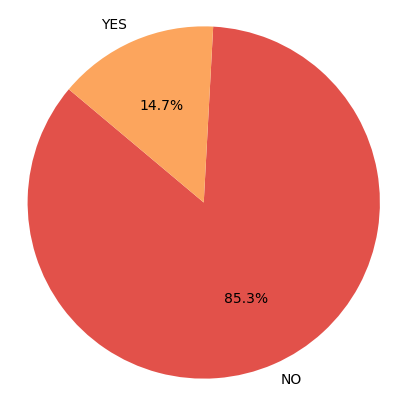

In [76]:
clinvar_nmd_counts = clinvar_final_pat['NMD_escape'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(clinvar_nmd_counts, 
        labels=clinvar_nmd_counts.index, 
        autopct='%1.1f%%', 
        startangle=140,
        colors=sns.color_palette("Spectral")) 
plt.axis('equal')
plt.savefig('images/nmd_counts_clinvar.png', bbox_inches='tight', dpi=300)
plt.show()


In [77]:
clinvar_final_pat['NMD_escape'].value_counts()

NMD_escape
NO     7102
YES    1228
Name: count, dtype: int64

In [78]:
clinvar_nmd_escape_df = clinvar_final_pat[clinvar_final_pat['NMD_escape'] == 'YES']
clinvar_nmd_undergo_df = clinvar_final_pat[clinvar_final_pat['NMD_escape'] == 'NO']

In [79]:
clinvar_nmd_escape_df.shape  # NMD(-)

(1228, 27)

In [80]:
clinvar_nmd_undergo_df.shape  # NMD(+)

(7102, 27)

In [81]:
clinvar_nmd_escape_df.to_csv('data/clinvar_nmd_escape_df.csv', index=False)
clinvar_nmd_undergo_df.to_csv('data/clinvar_nmd_undergo_df.csv', index=False)